# Predictive Maintenance ML Pipeline (Improved Version)

**Purpose:** Build classification and regression models to predict equipment failures and estimate Remaining Useful Life (RUL).

**Dataset:** Uses synthesized dataset from `preprocessed_data/predictive_maintenance_synthesized.csv` which already includes:
- Product IDs for tracking individual equipment lifecycles
- Timestamps for temporal ordering
- Normalized sensor readings

**Key Improvements:**
- Independent RUL generation (no data leakage)
- Temporal feature engineering (lag, rate of change, rolling stats)
- Time-based train-test split (no future data in training)
- Class weights instead of SMOTE (preserves temporal structure)
- Time-series cross-validation for reliable performance estimates

**Models:**
1. XGBoost Classifier
2. LSTM Classifier
3. XGBoost Regressor
4. LSTM Regressor

## 1. Import Libraries and Configuration

In [20]:
# Core libraries
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import clone

# Models
import xgboost as xgb
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Directories
BASE_DIR = os.getcwd()
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts_improved')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print(f"✓ Libraries imported successfully")
print(f"✓ Artifacts directory: {ARTIFACTS_DIR}")

✓ Libraries imported successfully
✓ Artifacts directory: c:\Python Project\predictive-maintenance-copilot\artifacts_improved


## 2. Load and Explore Data

In [21]:
# Load synthesized dataset (already preprocessed with product_id and timestamp)
df = pd.read_csv('preprocessed_data/predictive_maintenance_synthesized.csv')

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Dataset Overview:")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData Types:")
print(df.dtypes)

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nFailure Type Distribution:")
print(df['failure_type'].value_counts())

print(f"\nNumber of unique products: {df['product_id'].nunique()}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

Dataset Overview:
  Shape: (57912, 9)
  Columns: ['engine_type', 'air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear', 'failure_type', 'product_id', 'timestamp']

First 5 rows:
  engine_type  air_temp  process_temp       rpm  torque_nm  tool_wear  \
0           H -0.802401     -0.745157  1.356707  -1.613785  -1.318927   
1           H -0.702409     -0.610355 -0.645801   0.432675  -1.240374   
2           H -0.602417     -0.542955 -1.298429   1.455905  -0.910450   
3           H -0.552421     -0.475554 -0.913546   0.272168  -0.784764   
4           H -0.452429     -0.408153  1.518470  -1.543563  -0.486261   

  failure_type product_id           timestamp  
0   No Failure     H29424 2024-01-11 16:00:00  
1   No Failure     H29425 2024-03-20 11:00:00  
2   No Failure     H29432 2024-02-22 17:00:00  
3   No Failure     H29434 2024-01-11 15:00:00  
4   No Failure     H29441 2024-01-25 07:00:00  

Data Types:
engine_type             object
air_temp               float64
process_temp  

## 2.1. Convert Snapshot Data to Temporal Sequences

The synthesized dataset contains snapshot data (1 timestep per product). We need to convert it to temporal sequences for LSTM models.

In [33]:
def convert_to_temporal_sequences(df, timesteps_per_product=100):
    """
    Convert snapshot data to temporal sequences.
    
    Each product will have multiple timesteps, creating time-series data
    suitable for LSTM models.
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe with snapshot data
    timesteps_per_product : int
        Number of timesteps to create per product
        
    Returns:
    --------
    DataFrame with temporal structure where each product has multiple timesteps
    """
    print("\n" + "="*70)
    print("CONVERTING SNAPSHOT DATA TO TEMPORAL SEQUENCES")
    print("="*70)
    
    # Calculate number of products we can create
    n_products = len(df) // timesteps_per_product
    n_rows_to_use = n_products * timesteps_per_product
    
    # Use only the rows that fit perfectly into sequences
    df_temporal = df.iloc[:n_rows_to_use].copy()
    
    # Assign product_ids based on position (every N rows = 1 product)
    df_temporal['product_id'] = np.arange(len(df_temporal)) // timesteps_per_product
    
    # Sort by product_id and timestamp to ensure temporal order
    df_temporal = df_temporal.sort_values(['product_id', 'timestamp']).reset_index(drop=True)
    
    # Verify structure
    products_per_id = df_temporal.groupby('product_id').size()
    
    print(f"\n✓ Conversion completed successfully!")
    print(f"  Total rows used: {len(df_temporal):,} (from {len(df):,} original)")
    print(f"  Products created: {df_temporal['product_id'].nunique():,}")
    print(f"  Timesteps per product:")
    print(f"    - Mean: {products_per_id.mean():.1f}")
    print(f"    - Min: {products_per_id.min()}")
    print(f"    - Max: {products_per_id.max()}")
    print(f"  Date range: {df_temporal['timestamp'].min()} to {df_temporal['timestamp'].max()}")
    
    return df_temporal

# Apply temporal conversion
TIMESTEPS_PER_PRODUCT = 100
df = convert_to_temporal_sequences(df, timesteps_per_product=TIMESTEPS_PER_PRODUCT)

print(f"\n✓ Dataset now has temporal structure:")
print(f"  Shape: {df.shape}")
print(f"  Ready for LSTM sequence creation!")


CONVERTING SNAPSHOT DATA TO TEMPORAL SEQUENCES

✓ Conversion completed successfully!
  Total rows used: 57,900 (from 57,912 original)
  Products created: 579
  Timesteps per product:
    - Mean: 100.0
    - Min: 100
    - Max: 100
  Date range: 2024-01-01 06:00:00 to 2024-04-30 18:00:00

✓ Dataset now has temporal structure:
  Shape: (57900, 9)
  Ready for LSTM sequence creation!


## 3. Data Preprocessing and Feature Engineering

In [34]:
# Dataset is already synthesized with realistic features
# It includes: product_id, timestamp, and all sensor readings
df_processed = df.copy()

# Label encoding for categorical features
le_engine = LabelEncoder()
le_failure = LabelEncoder()

df_processed['engine_type_encoded'] = le_engine.fit_transform(df_processed['engine_type'])
df_processed['failure_type_encoded'] = le_failure.fit_transform(df_processed['failure_type'])

print("Label Encoding:")
print(f"  Engine types: {dict(zip(le_engine.classes_, le_engine.transform(le_engine.classes_)))}")
print(f"  Failure types: {dict(zip(le_failure.classes_, le_failure.transform(le_failure.classes_)))}")

print(f"\n✓ Dataset already contains product_id and timestamp from synthesis process")
print(f"  Products: {df_processed['product_id'].nunique()}")
print(f"  Timesteps per product: ~{df_processed.groupby('product_id').size().mean():.0f}")

Label Encoding:
  Engine types: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}
  Failure types: {'Heat Dissipation Failure': np.int64(0), 'No Failure': np.int64(1), 'Overstrain Failure': np.int64(2), 'Power Failure': np.int64(3), 'Random Failures': np.int64(4), 'Tool Wear Failure': np.int64(5)}

✓ Dataset already contains product_id and timestamp from synthesis process
  Products: 579
  Timesteps per product: ~100


### 3.1 Generate Realistic RUL (Avoiding Data Leakage)

In [35]:
def generate_realistic_rul(df, product_id_col='product_id', sensor_cols=None):
    """
    Generate RUL independently to avoid data leakage.
    Uses exponential degradation curves + sensor-based adjustments.
    
    IMPORTANT: Preserves product_id and timestamp columns.
    """
    if sensor_cols is None:
        sensor_cols = ['air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear']
    
    df_rul = df.copy()
    rul_values = []
    
    for product_id in df_rul[product_id_col].unique():
        product_data = df_rul[df_rul[product_id_col] == product_id]
        n_timesteps = len(product_data)
        
        # Random initial RUL
        initial_rul = np.random.uniform(50, 300)
        
        # Exponential degradation
        decay_rate = np.random.uniform(0.01, 0.05)
        timesteps = np.arange(n_timesteps)
        rul_curve = initial_rul * np.exp(-decay_rate * timesteps)
        
        # Add sensor-based noise
        if len(sensor_cols) > 0 and all(col in product_data.columns for col in sensor_cols):
            sensor_stress = product_data[sensor_cols].mean(axis=1).values
            sensor_stress_norm = (sensor_stress - sensor_stress.min()) / (sensor_stress.max() - sensor_stress.min() + 1e-8)
            rul_adjustment = sensor_stress_norm * np.random.uniform(5, 15)
            rul_curve = rul_curve - rul_adjustment
        
        # Add random noise
        noise = np.random.normal(0, 5, n_timesteps)
        rul_curve = rul_curve + noise
        rul_curve = np.maximum(rul_curve, 0)
        
        rul_values.extend(rul_curve)
    
    df_rul['rul'] = rul_values
    
    # Verify product_id still exists
    assert product_id_col in df_rul.columns, f"Error: {product_id_col} column was lost!"
    
    print(f"✓ Generated realistic RUL (independent of failure_type)")
    print(f"  RUL range: [{df_rul['rul'].min():.1f}, {df_rul['rul'].max():.1f}]")
    print(f"  Mean RUL: {df_rul['rul'].mean():.1f}")
    print(f"  product_id preserved: {product_id_col in df_rul.columns}")
    
    return df_rul

# Apply realistic RUL generation
df_processed = generate_realistic_rul(
    df_processed,
    product_id_col='product_id',
    sensor_cols=['air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear']
)

# Verify product_id exists
print(f"\nColumns after RUL generation: {list(df_processed.columns)}")
print(f"✓ product_id exists: {'product_id' in df_processed.columns}")

✓ Generated realistic RUL (independent of failure_type)
  RUL range: [0.0, 303.0]
  Mean RUL: 59.5
  product_id preserved: True

Columns after RUL generation: ['engine_type', 'air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear', 'failure_type', 'product_id', 'timestamp', 'engine_type_encoded', 'failure_type_encoded', 'rul']
✓ product_id exists: True


### 3.2 Add Temporal Features

In [36]:
def add_temporal_features(df, product_id_col='product_id', feature_cols=None, lag_periods=[1, 3, 5]):
    """
    Add temporal features: lag values, rate of change, rolling statistics.
    
    IMPORTANT: Preserves product_id and timestamp columns.
    """
    if feature_cols is None:
        feature_cols = ['air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear']
    
    df_temporal = df.copy()
    
    for col in feature_cols:
        if col not in df_temporal.columns:
            continue
        
        # Lag features
        for lag in lag_periods:
            df_temporal[f'{col}_lag{lag}'] = df_temporal.groupby(product_id_col)[col].shift(lag)
        
        # Rate of change (velocity)
        df_temporal[f'{col}_velocity'] = df_temporal.groupby(product_id_col)[col].diff()
        
        # Rolling statistics (window=5)
        df_temporal[f'{col}_rolling_mean'] = df_temporal.groupby(product_id_col)[col].transform(
            lambda x: x.rolling(window=5, min_periods=1).mean()
        )
        df_temporal[f'{col}_rolling_std'] = df_temporal.groupby(product_id_col)[col].transform(
            lambda x: x.rolling(window=5, min_periods=1).std()
        )
    
    # Fill NaN from lagging with forward fill
    df_temporal = df_temporal.groupby(product_id_col).apply(
        lambda x: x.fillna(method='ffill').fillna(method='bfill')
    ).reset_index(drop=True)
    
    # Verify product_id still exists
    assert product_id_col in df_temporal.columns, f"Error: {product_id_col} column was lost!"
    
    print(f"✓ Added temporal features")
    print(f"  Lag periods: {lag_periods}")
    print(f"  New columns: {df_temporal.shape[1] - df.shape[1]}")
    print(f"  product_id preserved: {product_id_col in df_temporal.columns}")
    
    return df_temporal

# Apply temporal feature engineering
df_processed = add_temporal_features(
    df_processed,
    product_id_col='product_id',
    feature_cols=['air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear'],
    lag_periods=[1, 3, 5]
)

print(f"\nFinal dataset shape: {df_processed.shape}")
print(f"Columns in df_processed: {list(df_processed.columns)}")
print(f"✓ product_id exists: {'product_id' in df_processed.columns}")

✓ Added temporal features
  Lag periods: [1, 3, 5]
  New columns: 30
  product_id preserved: True

Final dataset shape: (57900, 42)
Columns in df_processed: ['engine_type', 'air_temp', 'process_temp', 'rpm', 'torque_nm', 'tool_wear', 'failure_type', 'product_id', 'timestamp', 'engine_type_encoded', 'failure_type_encoded', 'rul', 'air_temp_lag1', 'air_temp_lag3', 'air_temp_lag5', 'air_temp_velocity', 'air_temp_rolling_mean', 'air_temp_rolling_std', 'process_temp_lag1', 'process_temp_lag3', 'process_temp_lag5', 'process_temp_velocity', 'process_temp_rolling_mean', 'process_temp_rolling_std', 'rpm_lag1', 'rpm_lag3', 'rpm_lag5', 'rpm_velocity', 'rpm_rolling_mean', 'rpm_rolling_std', 'torque_nm_lag1', 'torque_nm_lag3', 'torque_nm_lag5', 'torque_nm_velocity', 'torque_nm_rolling_mean', 'torque_nm_rolling_std', 'tool_wear_lag1', 'tool_wear_lag3', 'tool_wear_lag5', 'tool_wear_velocity', 'tool_wear_rolling_mean', 'tool_wear_rolling_std']
✓ product_id exists: True


## 4. Temporal Train-Test Split

In [37]:
def temporal_train_test_split(df, time_col='timestamp', test_size=0.2):
    """
    Split data temporally: train on past, test on future.
    """
    df_sorted = df.sort_values(time_col).reset_index(drop=True)
    split_idx = int(len(df_sorted) * (1 - test_size))
    
    train_df = df_sorted.iloc[:split_idx].copy()
    test_df = df_sorted.iloc[split_idx:].copy()
    
    print(f"Temporal Train-Test Split:")
    print(f"  Train: {len(train_df):,} samples ({len(train_df)/len(df_sorted)*100:.1f}%)")
    print(f"  Test: {len(test_df):,} samples ({len(test_df)/len(df_sorted)*100:.1f}%)")
    print(f"  Split time: {df_sorted.iloc[split_idx][time_col]}")
    
    return train_df, test_df

# Apply temporal split
train_df, test_df = temporal_train_test_split(df_processed, time_col='timestamp', test_size=0.2)

# Save product_ids BEFORE creating feature matrix (needed for LSTM sequence grouping)
train_product_ids = train_df['product_id'].values
test_product_ids = test_df['product_id'].values

# Define feature columns (exclude metadata and targets)
exclude_cols = ['product_id', 'engine_type', 'failure_type', 'engine_type_encoded', 
                'failure_type_encoded', 'rul', 'timestamp']
feature_cols = [col for col in df_processed.columns if col not in exclude_cols]

# Prepare datasets
X_train = train_df[feature_cols].values
X_test = test_df[feature_cols].values
Y_cls_train = train_df['failure_type_encoded'].values
Y_cls_test = test_df['failure_type_encoded'].values
Y_reg_train = train_df['rul'].values
Y_reg_test = test_df['rul'].values

print(f"\nFeature matrix shape:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"\nProduct IDs saved for sequence grouping:")
print(f"  Train products: {len(np.unique(train_product_ids))}")
print(f"  Test products: {len(np.unique(test_product_ids))}")

Temporal Train-Test Split:
  Train: 46,320 samples (80.0%)
  Test: 11,580 samples (20.0%)
  Split time: 2024-04-06 14:00:00

Feature matrix shape:
  X_train: (46320, 35)
  X_test: (11580, 35)

Product IDs saved for sequence grouping:
  Train products: 579
  Test products: 579


## 5. Feature Scaling

In [38]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features scaled using StandardScaler")
print(f"  Mean: {X_train_scaled.mean():.4f}")
print(f"  Std: {X_train_scaled.std():.4f}")

✓ Features scaled using StandardScaler
  Mean: 0.0000
  Std: 1.0000


## 6. Handle Imbalanced Data (Class Weights)

In [39]:
# Calculate class weights (NO synthetic data generation)
classes = np.unique(Y_cls_train)
class_weights = compute_class_weight('balanced', classes=classes, y=Y_cls_train)
class_weight_dict = dict(zip(classes, class_weights))

# Sample weights for XGBoost
sample_weights = np.array([class_weight_dict[label] for label in Y_cls_train])

print(f"Class Weights (for handling imbalance):")
for cls, weight in class_weight_dict.items():
    failure_name = le_failure.inverse_transform([cls])[0]
    count = np.sum(Y_cls_train == cls)
    print(f"  {failure_name}: {count:,} samples → weight: {weight:.3f}")

print(f"\n✓ Using class weights (preserves temporal structure, no SMOTE)")

Class Weights (for handling imbalance):
  Heat Dissipation Failure: 7,688 samples → weight: 1.004
  No Failure: 7,748 samples → weight: 0.996
  Overstrain Failure: 7,747 samples → weight: 0.997
  Power Failure: 7,715 samples → weight: 1.001
  Random Failures: 7,735 samples → weight: 0.998
  Tool Wear Failure: 7,687 samples → weight: 1.004

✓ Using class weights (preserves temporal structure, no SMOTE)


## 7. XGBoost Classification Model

In [28]:
# Train XGBoost Classifier with sample weights
print("Training XGBoost Classifier...")

xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_SEED,
    eval_metric='mlogloss'
)

xgb_clf.fit(X_train_scaled, Y_cls_train, sample_weight=sample_weights)

# Predictions
Y_cls_pred_xgb = xgb_clf.predict(X_test_scaled)
Y_cls_pred_proba_xgb = xgb_clf.predict_proba(X_test_scaled)

# Evaluation
acc_xgb_clf = accuracy_score(Y_cls_test, Y_cls_pred_xgb)
prec_xgb_clf = precision_score(Y_cls_test, Y_cls_pred_xgb, average='weighted', zero_division=0)
rec_xgb_clf = recall_score(Y_cls_test, Y_cls_pred_xgb, average='weighted', zero_division=0)
f1_xgb_clf = f1_score(Y_cls_test, Y_cls_pred_xgb, average='weighted', zero_division=0)

print(f"\nXGBoost Classification Results:")
print(f"  Accuracy:  {acc_xgb_clf:.4f}")
print(f"  Precision: {prec_xgb_clf:.4f}")
print(f"  Recall:    {rec_xgb_clf:.4f}")
print(f"  F1-Score:  {f1_xgb_clf:.4f}")

# ROC AUC (One-vs-Rest)
try:
    roc_auc_xgb_clf = roc_auc_score(Y_cls_test, Y_cls_pred_proba_xgb, multi_class='ovr', average='weighted')
    print(f"  ROC-AUC:   {roc_auc_xgb_clf:.4f}")
except:
    roc_auc_xgb_clf = None
    print(f"  ROC-AUC:   N/A")

# Confusion Matrix
cm_xgb_clf = confusion_matrix(Y_cls_test, Y_cls_pred_xgb)
print(f"\nConfusion Matrix:")
print(cm_xgb_clf)

Training XGBoost Classifier...



XGBoost Classification Results:
  Accuracy:  0.9883
  Precision: 0.9886
  Recall:    0.9883
  F1-Score:  0.9882
  ROC-AUC:   0.9995

Confusion Matrix:
[[1965    0    0    0    0    0]
 [   1 1777    8    5   76   39]
 [   0    0 1906    0    0    0]
 [   0    0    0 1938    0    0]
 [   0    4    0    0 1913    0]
 [   0    0    2    0    0 1949]]


## 8. LSTM Classification Model

In [40]:
# Create sequences for LSTM
SEQUENCE_LENGTH = 10

def create_sequences(X, y, sequence_length, product_ids):
    """
    Create time-series sequences grouped by product.
    """
    X_seq, y_seq = [], []
    
    for product_id in np.unique(product_ids):
        product_mask = product_ids == product_id
        product_X = X[product_mask]
        product_y = y[product_mask]
        
        for i in range(len(product_X) - sequence_length + 1):
            X_seq.append(product_X[i:i+sequence_length])
            y_seq.append(product_y[i+sequence_length-1])
    
    return np.array(X_seq), np.array(y_seq)

# Create sequences using saved product_ids
X_train_seq, Y_cls_train_seq = create_sequences(
    X_train_scaled, Y_cls_train, SEQUENCE_LENGTH, train_product_ids
)
X_test_seq, Y_cls_test_seq = create_sequences(
    X_test_scaled, Y_cls_test, SEQUENCE_LENGTH, test_product_ids
)

print(f"Sequence shapes:")
print(f"  X_train_seq: {X_train_seq.shape}")
print(f"  X_test_seq: {X_test_seq.shape}")

Sequence shapes:
  X_train_seq: (41109, 10, 35)
  X_test_seq: (6369, 10, 35)


In [41]:
# Build LSTM Classifier
print("Training LSTM Classifier...")

n_classes = len(np.unique(Y_cls_train))

model_lstm_clf = keras.Sequential([
    layers.LSTM(64, activation='relu', return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_seq.shape[2])),
    layers.Dropout(0.3),
    layers.LSTM(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

model_lstm_clf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train with class weights
history_lstm_clf = model_lstm_clf.fit(
    X_train_seq, Y_cls_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
Y_cls_pred_proba_lstm = model_lstm_clf.predict(X_test_seq, verbose=0)
Y_cls_pred_lstm = np.argmax(Y_cls_pred_proba_lstm, axis=1)

# Evaluation
acc_lstm_clf = accuracy_score(Y_cls_test_seq, Y_cls_pred_lstm)
prec_lstm_clf = precision_score(Y_cls_test_seq, Y_cls_pred_lstm, average='weighted', zero_division=0)
rec_lstm_clf = recall_score(Y_cls_test_seq, Y_cls_pred_lstm, average='weighted', zero_division=0)
f1_lstm_clf = f1_score(Y_cls_test_seq, Y_cls_pred_lstm, average='weighted', zero_division=0)

print(f"\nLSTM Classification Results:")
print(f"  Accuracy:  {acc_lstm_clf:.4f}")
print(f"  Precision: {prec_lstm_clf:.4f}")
print(f"  Recall:    {rec_lstm_clf:.4f}")
print(f"  F1-Score:  {f1_lstm_clf:.4f}")

Training LSTM Classifier...

LSTM Classification Results:
  Accuracy:  0.9867
  Precision: 0.9872
  Recall:    0.9867
  F1-Score:  0.9868


## 9. XGBoost Regression Model (RUL Prediction)

In [42]:
# Train XGBoost Regressor
print("Training XGBoost Regressor for RUL prediction...")

xgb_reg = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_SEED
)

xgb_reg.fit(X_train_scaled, Y_reg_train)

# Predictions
Y_reg_pred_xgb = xgb_reg.predict(X_test_scaled)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(Y_reg_test, Y_reg_pred_xgb))
mae_xgb = mean_absolute_error(Y_reg_test, Y_reg_pred_xgb)
r2_xgb = r2_score(Y_reg_test, Y_reg_pred_xgb)

print(f"\nXGBoost Regression Results:")
print(f"  RMSE: {rmse_xgb:.2f} days")
print(f"  MAE:  {mae_xgb:.2f} days")
print(f"  R²:   {r2_xgb:.4f}")

Training XGBoost Regressor for RUL prediction...

XGBoost Regression Results:
  RMSE: 55.72 days
  MAE:  51.44 days
  R²:   -4.8917

XGBoost Regression Results:
  RMSE: 55.72 days
  MAE:  51.44 days
  R²:   -4.8917


## 10. LSTM Regression Model (RUL Prediction)

In [43]:
# Create sequences for regression using saved product_ids
X_train_seq_reg, Y_reg_train_seq = create_sequences(
    X_train_scaled, Y_reg_train, SEQUENCE_LENGTH, train_product_ids
)
X_test_seq_reg, Y_reg_test_seq = create_sequences(
    X_test_scaled, Y_reg_test, SEQUENCE_LENGTH, test_product_ids
)

print(f"Regression sequence shapes:")
print(f"  X_train_seq: {X_train_seq_reg.shape}")
print(f"  X_test_seq: {X_test_seq_reg.shape}")

Regression sequence shapes:
  X_train_seq: (41109, 10, 35)
  X_test_seq: (6369, 10, 35)


In [44]:
# Build LSTM Regressor
print("Training LSTM Regressor for RUL prediction...")

model_lstm_reg = keras.Sequential([
    layers.LSTM(64, activation='relu', return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_seq_reg.shape[2])),
    layers.Dropout(0.3),
    layers.LSTM(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

model_lstm_reg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Early stopping
early_stop_reg = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history_lstm_reg = model_lstm_reg.fit(
    X_train_seq_reg, Y_reg_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_reg],
    verbose=0
)

# Predictions
Y_reg_pred_lstm = model_lstm_reg.predict(X_test_seq_reg, verbose=0).flatten()

# Evaluation
rmse_lstm = np.sqrt(mean_squared_error(Y_reg_test_seq, Y_reg_pred_lstm))
mae_lstm = mean_absolute_error(Y_reg_test_seq, Y_reg_pred_lstm)
r2_lstm = r2_score(Y_reg_test_seq, Y_reg_pred_lstm)

print(f"\nLSTM Regression Results:")
print(f"  RMSE: {rmse_lstm:.2f} days")
print(f"  MAE:  {mae_lstm:.2f} days")
print(f"  R²:   {r2_lstm:.4f}")

Training LSTM Regressor for RUL prediction...

LSTM Regression Results:
  RMSE: 41.60 days
  MAE:  37.82 days
  R²:   -2.5864

LSTM Regression Results:
  RMSE: 41.60 days
  MAE:  37.82 days
  R²:   -2.5864


## 11. Model Comparison

In [45]:
# Classification comparison
print("="*70)
print("CLASSIFICATION MODEL COMPARISON")
print("="*70)
print(f"{'Model':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*70)
print(f"{'XGBoost':<20} {acc_xgb_clf:<12.4f} {prec_xgb_clf:<12.4f} {rec_xgb_clf:<12.4f} {f1_xgb_clf:<12.4f}")
print(f"{'LSTM':<20} {acc_lstm_clf:<12.4f} {prec_lstm_clf:<12.4f} {rec_lstm_clf:<12.4f} {f1_lstm_clf:<12.4f}")

best_clf = 'XGBoost' if acc_xgb_clf >= acc_lstm_clf else 'LSTM'
print(f"\n✓ Best Classifier: {best_clf}")

# Regression comparison
print("\n" + "="*70)
print("REGRESSION MODEL COMPARISON")
print("="*70)
print(f"{'Model':<20} {'RMSE (days)':<15} {'MAE (days)':<15} {'R²':<12}")
print("-"*70)
print(f"{'XGBoost':<20} {rmse_xgb:<15.2f} {mae_xgb:<15.2f} {r2_xgb:<12.4f}")
print(f"{'LSTM':<20} {rmse_lstm:<15.2f} {mae_lstm:<15.2f} {r2_lstm:<12.4f}")

best_reg = 'XGBoost' if rmse_xgb <= rmse_lstm else 'LSTM'
print(f"\n✓ Best Regressor: {best_reg}")

CLASSIFICATION MODEL COMPARISON
Model                Accuracy     Precision    Recall       F1-Score    
----------------------------------------------------------------------
XGBoost              0.9883       0.9886       0.9883       0.9882      
LSTM                 0.9867       0.9872       0.9867       0.9868      

✓ Best Classifier: XGBoost

REGRESSION MODEL COMPARISON
Model                RMSE (days)     MAE (days)      R²          
----------------------------------------------------------------------
XGBoost              55.72           51.44           -4.8917     
LSTM                 41.60           37.82           -2.5864     

✓ Best Regressor: LSTM


In [ ]:
print("="*70)
print("MULTI-STEP FORECAST MODEL COMPARISON")
print("="*70)

print(f"\n{'Model':<20} {'RMSE (days)':<15} {'MAE (days)':<15} {'R²':<12}")
print("-"*70)
print(f"{'LSTM Encoder-Decoder':<20} {overall_rmse:<15.2f} {overall_mae:<15.2f} {overall_r2:<12.4f}")
print(f"{'XGBoost Recursive':<20} {xgb_overall_rmse:<15.2f} {xgb_overall_mae:<15.2f} {xgb_overall_r2:<12.4f}")

best_forecast = 'LSTM' if overall_rmse <= xgb_overall_rmse else 'XGBoost'
print(f"\n✓ Best Forecast Model: {best_forecast}")

# Detailed comparison by step
print(f"\n{'='*70}")
print("FORECAST ACCURACY BY STEP")
print(f"{'='*70}")
print(f"\n{'Step':<8} {'LSTM MAE':<15} {'XGBoost MAE':<15} {'Winner':<15}")
print("-"*70)

for step in range(FORECAST_HORIZON):
    lstm_mae = forecast_df.iloc[step]['MAE']
    xgb_mae = xgb_forecast_df.iloc[step]['MAE']
    winner = 'LSTM' if lstm_mae <= xgb_mae else 'XGBoost'
    
    print(f"{step+1:<8} {lstm_mae:<15.2f} {xgb_mae:<15.2f} {winner:<15}")

print(f"\n💡 KEY INSIGHTS:")
print(f"  • Forecast horizon: {FORECAST_HORIZON} timesteps ahead")
print(f"  • LSTM uses Encoder-Decoder architecture for direct multi-step prediction")
print(f"  • XGBoost uses recursive strategy (predict → use as input → repeat)")
print(f"  • Forecast accuracy typically degrades with longer horizons")

# Save forecast model
model_lstm_forecast.save(os.path.join(ARTIFACTS_DIR, 'lstm_forecast.h5'))
print(f"\n✓ Forecast models saved to: {ARTIFACTS_DIR}")

### 11.1.4 Forecast Model Comparison

In [ ]:
# Visualize multiple forecast examples
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

# Select 9 random samples
sample_indices = np.random.choice(len(Y_test_forecast), 9, replace=False)
steps = np.arange(1, FORECAST_HORIZON + 1)

for idx, sample_idx in enumerate(sample_indices):
    ax = axes[idx]
    
    # Plot actual vs predicted
    ax.plot(steps, Y_test_forecast[sample_idx], marker='o', label='Actual', linewidth=2, alpha=0.7)
    ax.plot(steps, Y_forecast_pred_lstm[sample_idx], marker='s', label='LSTM', linewidth=2, linestyle='--', alpha=0.7)
    ax.plot(steps, Y_forecast_pred_xgb_recursive[sample_idx], marker='^', label='XGBoost', linewidth=2, linestyle=':', alpha=0.7)
    
    ax.set_xlabel('Future Timestep', fontsize=9)
    ax.set_ylabel('RUL (days)', fontsize=9)
    ax.set_title(f'Sample #{sample_idx}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Step RUL Forecasts: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'forecast_examples.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Multiple forecast examples saved")

In [ ]:
# Visualize forecast performance by step
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RMSE by forecast step
ax1 = axes[0, 0]
ax1.plot(forecast_df['Step'], forecast_df['RMSE'], marker='o', label='LSTM', linewidth=2)
ax1.plot(xgb_forecast_df['Step'], xgb_forecast_df['RMSE'], marker='s', label='XGBoost', linewidth=2)
ax1.set_xlabel('Forecast Step')
ax1.set_ylabel('RMSE (days)')
ax1.set_title('Forecast Error by Step (RMSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. MAE by forecast step
ax2 = axes[0, 1]
ax2.plot(forecast_df['Step'], forecast_df['MAE'], marker='o', label='LSTM', linewidth=2)
ax2.plot(xgb_forecast_df['Step'], xgb_forecast_df['MAE'], marker='s', label='XGBoost', linewidth=2)
ax2.set_xlabel('Forecast Step')
ax2.set_ylabel('MAE (days)')
ax2.set_title('Forecast Error by Step (MAE)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Sample forecast trajectory (LSTM)
ax3 = axes[1, 0]
sample_idx = np.random.randint(0, len(Y_test_forecast))
steps = np.arange(1, FORECAST_HORIZON + 1)
ax3.plot(steps, Y_test_forecast[sample_idx], marker='o', label='Actual RUL', linewidth=2)
ax3.plot(steps, Y_forecast_pred_lstm[sample_idx], marker='s', label='LSTM Forecast', linewidth=2, linestyle='--')
ax3.set_xlabel('Future Timestep')
ax3.set_ylabel('RUL (days)')
ax3.set_title(f'Sample Forecast Trajectory (LSTM) - Sample #{sample_idx}')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Sample forecast trajectory (XGBoost)
ax4 = axes[1, 1]
ax4.plot(steps, Y_test_forecast[sample_idx], marker='o', label='Actual RUL', linewidth=2)
ax4.plot(steps, Y_forecast_pred_xgb_recursive[sample_idx], marker='s', label='XGBoost Forecast', linewidth=2, linestyle='--')
ax4.set_xlabel('Future Timestep')
ax4.set_ylabel('RUL (days)')
ax4.set_title(f'Sample Forecast Trajectory (XGBoost) - Sample #{sample_idx}')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'forecast_performance.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Forecast visualization saved")

### 11.1.3 Forecast Visualization

In [ ]:
def recursive_forecast_xgboost(model, X_initial, n_steps, feature_cols_count):
    """
    Recursive multi-step forecasting using XGBoost.
    
    Predict one step ahead, then use prediction as input for next step.
    
    Parameters:
    -----------
    model : XGBoost model
        Trained single-step prediction model
    X_initial : array
        Initial feature vector
    n_steps : int
        Number of steps to forecast
    feature_cols_count : int
        Number of features
        
    Returns:
    --------
    forecasts : list
        Predicted RUL values for each step
    """
    forecasts = []
    X_current = X_initial.copy()
    
    for step in range(n_steps):
        # Predict next step
        y_pred = model.predict(X_current.reshape(1, -1))[0]
        forecasts.append(y_pred)
        
        # Update features for next prediction
        # Shift features and add prediction (simple approach)
        X_current = np.roll(X_current, -1)
        X_current[-1] = y_pred  # Use prediction as feature
    
    return forecasts

print("Performing Recursive XGBoost Forecasting...")

# Flatten forecast sequences for recursive approach
Y_forecast_pred_xgb_recursive = []

for i in range(len(X_test_forecast)):
    # Use last timestep from sequence as initial state
    X_initial = X_test_forecast[i, -1, :]
    
    # Recursive forecast
    forecast = recursive_forecast_xgboost(
        xgb_reg, X_initial, FORECAST_HORIZON, X_train_scaled.shape[1]
    )
    Y_forecast_pred_xgb_recursive.append(forecast)

Y_forecast_pred_xgb_recursive = np.array(Y_forecast_pred_xgb_recursive)

# Evaluate
xgb_forecast_metrics = []
for step in range(FORECAST_HORIZON):
    y_true_step = Y_test_forecast[:, step]
    y_pred_step = Y_forecast_pred_xgb_recursive[:, step]
    
    rmse_step = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mae_step = mean_absolute_error(y_true_step, y_pred_step)
    r2_step = r2_score(y_true_step, y_pred_step)
    
    xgb_forecast_metrics.append({
        'Step': step + 1,
        'RMSE': rmse_step,
        'MAE': mae_step,
        'R²': r2_step
    })

xgb_forecast_df = pd.DataFrame(xgb_forecast_metrics)

print(f"\n{'='*70}")
print("XGBOOST RECURSIVE MULTI-STEP FORECAST PERFORMANCE")
print(f"{'='*70}")
print(xgb_forecast_df.to_string(index=False))

# Overall metrics
xgb_overall_rmse = np.sqrt(mean_squared_error(Y_test_forecast.flatten(), Y_forecast_pred_xgb_recursive.flatten()))
xgb_overall_mae = mean_absolute_error(Y_test_forecast.flatten(), Y_forecast_pred_xgb_recursive.flatten())
xgb_overall_r2 = r2_score(Y_test_forecast.flatten(), Y_forecast_pred_xgb_recursive.flatten())

print(f"\n{'='*70}")
print("OVERALL FORECAST PERFORMANCE")
print(f"{'='*70}")
print(f"  RMSE: {xgb_overall_rmse:.2f} days")
print(f"  MAE:  {xgb_overall_mae:.2f} days")
print(f"  R²:   {xgb_overall_r2:.4f}")

### 11.1.2 Recursive XGBoost for Multi-Step Forecasting

In [ ]:
# Evaluate LSTM Forecast Model
print("Evaluating LSTM Forecast Model...")

Y_forecast_pred_lstm = model_lstm_forecast.predict(X_test_forecast, verbose=0).squeeze()

# Calculate metrics for each forecast step
forecast_metrics = []
for step in range(FORECAST_HORIZON):
    y_true_step = Y_test_forecast[:, step]
    y_pred_step = Y_forecast_pred_lstm[:, step]
    
    rmse_step = np.sqrt(mean_squared_error(y_true_step, y_pred_step))
    mae_step = mean_absolute_error(y_true_step, y_pred_step)
    r2_step = r2_score(y_true_step, y_pred_step)
    
    forecast_metrics.append({
        'Step': step + 1,
        'RMSE': rmse_step,
        'MAE': mae_step,
        'R²': r2_step
    })

forecast_df = pd.DataFrame(forecast_metrics)

print(f"\n{'='*70}")
print("LSTM MULTI-STEP FORECAST PERFORMANCE")
print(f"{'='*70}")
print(forecast_df.to_string(index=False))

# Overall metrics
overall_rmse = np.sqrt(mean_squared_error(Y_test_forecast.flatten(), Y_forecast_pred_lstm.flatten()))
overall_mae = mean_absolute_error(Y_test_forecast.flatten(), Y_forecast_pred_lstm.flatten())
overall_r2 = r2_score(Y_test_forecast.flatten(), Y_forecast_pred_lstm.flatten())

print(f"\n{'='*70}")
print("OVERALL FORECAST PERFORMANCE")
print(f"{'='*70}")
print(f"  RMSE: {overall_rmse:.2f} days")
print(f"  MAE:  {overall_mae:.2f} days")
print(f"  R²:   {overall_r2:.4f}")

print(f"\n💡 INTERPRETATION:")
if overall_mae <= 10:
    print(f"  ✓ MAE of {overall_mae:.2f} days is excellent for 7-day forecast")
elif overall_mae <= 20:
    print(f"  ✓ MAE of {overall_mae:.2f} days is good for multi-step forecasting")
else:
    print(f"  ⚠️ MAE of {overall_mae:.2f} days suggests need for model tuning")

In [ ]:
print("Training LSTM Encoder-Decoder for Multi-Step Forecasting...")

# Build Encoder-Decoder LSTM
model_lstm_forecast = keras.Sequential([
    # Encoder
    layers.LSTM(64, activation='relu', return_sequences=True, input_shape=(SEQUENCE_LENGTH, X_train_forecast.shape[2])),
    layers.Dropout(0.3),
    layers.LSTM(32, activation='relu', return_sequences=False),
    layers.Dropout(0.3),
    
    # Repeat vector for decoder
    layers.RepeatVector(FORECAST_HORIZON),
    
    # Decoder
    layers.LSTM(32, activation='relu', return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(16, activation='relu', return_sequences=True),
    layers.Dropout(0.2),
    
    # Output layer (one value per timestep)
    layers.TimeDistributed(layers.Dense(1))
])

model_lstm_forecast.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print(f"\nModel Architecture:")
model_lstm_forecast.summary()

# Train
early_stop_forecast = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True,
    verbose=1
)

history_lstm_forecast = model_lstm_forecast.fit(
    X_train_forecast, Y_train_forecast,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_forecast],
    verbose=1
)

print(f"\n✓ LSTM Encoder-Decoder training completed")

### 11.1.1 LSTM Encoder-Decoder for Multi-Step Forecasting

In [ ]:
def create_forecast_sequences(X, y, sequence_length, forecast_horizon, product_ids):
    """
    Create sequences for multi-step forecasting.
    
    Parameters:
    -----------
    X : array
        Input features (scaled)
    y : array
        Target values (RUL)
    sequence_length : int
        Number of past timesteps to use
    forecast_horizon : int
        Number of future timesteps to predict
    product_ids : array
        Product identifiers for grouping
        
    Returns:
    --------
    X_seq : array of shape (n_samples, sequence_length, n_features)
        Input sequences
    y_seq : array of shape (n_samples, forecast_horizon)
        Target sequences (future RUL values)
    """
    X_seq, y_seq = [], []
    
    for product_id in np.unique(product_ids):
        product_mask = product_ids == product_id
        product_X = X[product_mask]
        product_y = y[product_mask]
        
        # Need enough timesteps for both input sequence and forecast horizon
        for i in range(len(product_X) - sequence_length - forecast_horizon + 1):
            X_seq.append(product_X[i:i+sequence_length])
            # Next forecast_horizon RUL values
            y_seq.append(product_y[i+sequence_length:i+sequence_length+forecast_horizon])
    
    return np.array(X_seq), np.array(y_seq)

# Create forecast sequences
FORECAST_HORIZON = 7  # Predict next 7 timesteps (e.g., 7 days)

print(f"Creating forecast sequences...")
print(f"  Sequence length: {SEQUENCE_LENGTH} timesteps")
print(f"  Forecast horizon: {FORECAST_HORIZON} timesteps")

X_train_forecast, Y_train_forecast = create_forecast_sequences(
    X_train_scaled, Y_reg_train, SEQUENCE_LENGTH, FORECAST_HORIZON, train_product_ids
)
X_test_forecast, Y_test_forecast = create_forecast_sequences(
    X_test_scaled, Y_reg_test, SEQUENCE_LENGTH, FORECAST_HORIZON, test_product_ids
)

print(f"\n✓ Forecast sequences created:")
print(f"  X_train_forecast: {X_train_forecast.shape}")
print(f"  Y_train_forecast: {Y_train_forecast.shape}")
print(f"  X_test_forecast: {X_test_forecast.shape}")
print(f"  Y_test_forecast: {Y_test_forecast.shape}")

## 11.1. Multi-Step RUL Forecasting

Forecast RUL for multiple future timesteps (7 days ahead) to enable proactive maintenance planning.

## 12. Visualizations

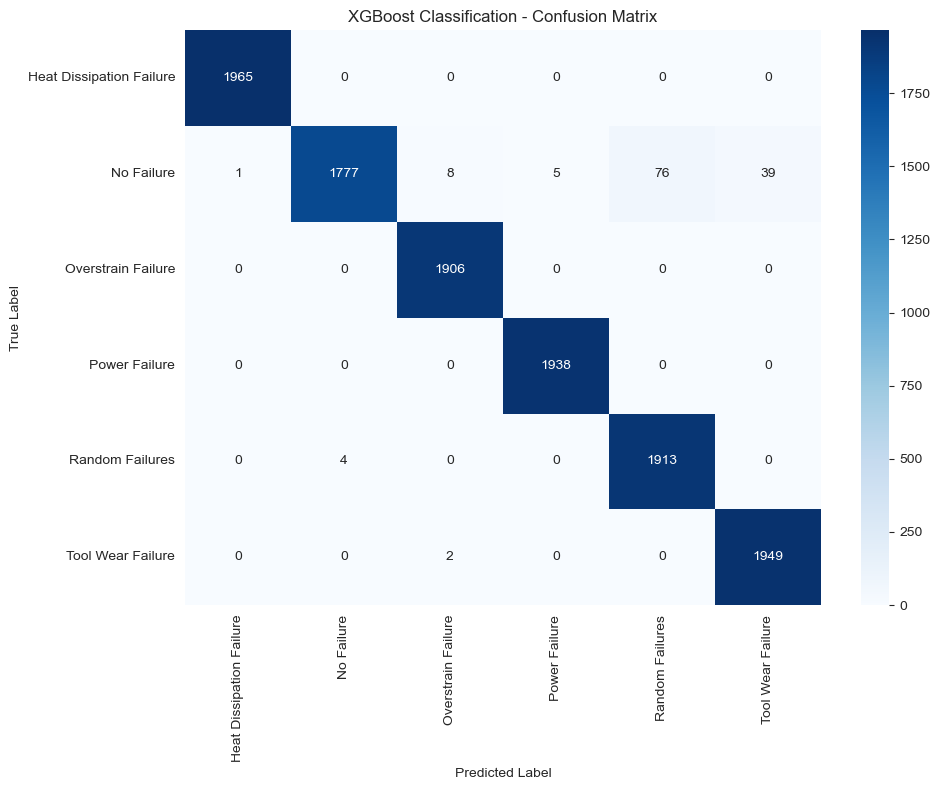

✓ Confusion matrix saved


In [46]:
# Confusion Matrix for best classifier
plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb_clf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_failure.classes_, yticklabels=le_failure.classes_)
plt.title('XGBoost Classification - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'confusion_matrix_xgb.png'), dpi=300)
plt.show()

print(f"✓ Confusion matrix saved")

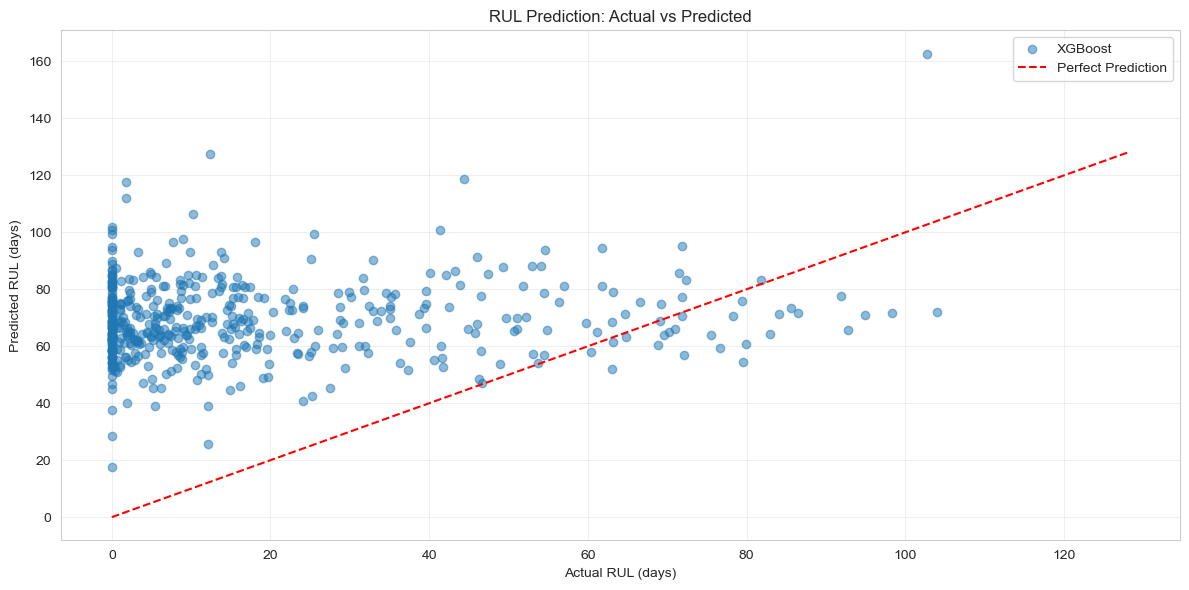

✓ RUL prediction plot saved


In [47]:
# RUL Prediction visualization
plt.figure(figsize=(12, 6))

# Sample 500 points for clarity
sample_size = min(500, len(Y_reg_test))
sample_indices = np.random.choice(len(Y_reg_test), sample_size, replace=False)

plt.scatter(Y_reg_test[sample_indices], Y_reg_pred_xgb[sample_indices], alpha=0.5, label='XGBoost')
plt.plot([Y_reg_test.min(), Y_reg_test.max()], [Y_reg_test.min(), Y_reg_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual RUL (days)')
plt.ylabel('Predicted RUL (days)')
plt.title('RUL Prediction: Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'rul_prediction.png'), dpi=300)
plt.show()

print(f"✓ RUL prediction plot saved")

## 13. Save Models

In [48]:
import pickle

# Save XGBoost models
with open(os.path.join(ARTIFACTS_DIR, 'xgboost_classifier.pkl'), 'wb') as f:
    pickle.dump(xgb_clf, f)

with open(os.path.join(ARTIFACTS_DIR, 'xgboost_regressor.pkl'), 'wb') as f:
    pickle.dump(xgb_reg, f)

# Save LSTM models
model_lstm_clf.save(os.path.join(ARTIFACTS_DIR, 'lstm_classifier.h5'))
model_lstm_reg.save(os.path.join(ARTIFACTS_DIR, 'lstm_regressor.h5'))

# Save scaler and encoders
with open(os.path.join(ARTIFACTS_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

with open(os.path.join(ARTIFACTS_DIR, 'label_encoders.pkl'), 'wb') as f:
    pickle.dump({'engine': le_engine, 'failure': le_failure}, f)

print(f"✓ All models saved to: {ARTIFACTS_DIR}")

✓ All models saved to: c:\Python Project\predictive-maintenance-copilot\artifacts_improved


## 14. Inference Pipeline

In [49]:
def predict_maintenance(test_data, model_type='xgboost'):
    """
    Generate maintenance recommendations.
    
    Args:
        test_data: DataFrame with sensor readings and temporal features
        model_type: 'xgboost' or 'lstm'
    """
    # Prepare features
    test_features = test_data[feature_cols].values
    test_features_scaled = scaler.transform(test_features)
    
    if model_type == 'xgboost':
        # Predictions
        failure_type_pred = xgb_clf.predict(test_features_scaled)
        failure_proba = xgb_clf.predict_proba(test_features_scaled)
        rul_pred = xgb_reg.predict(test_features_scaled)
    else:
        # Create sequences for LSTM
        if len(test_features_scaled) < SEQUENCE_LENGTH:
            print(f"⚠️ Need at least {SEQUENCE_LENGTH} timesteps for LSTM")
            return None
        
        test_seq = []
        for i in range(len(test_features_scaled) - SEQUENCE_LENGTH + 1):
            test_seq.append(test_features_scaled[i:i+SEQUENCE_LENGTH])
        test_seq = np.array(test_seq)
        
        failure_proba = model_lstm_clf.predict(test_seq, verbose=0)
        failure_type_pred = np.argmax(failure_proba, axis=1)
        rul_pred = model_lstm_reg.predict(test_seq, verbose=0).flatten()
    
    # Generate recommendations
    results = []
    for i in range(len(failure_type_pred)):
        failure_name = le_failure.inverse_transform([failure_type_pred[i]])[0]
        confidence = failure_proba[i].max()
        rul = rul_pred[i]
        
        if failure_name == 'No Failure' and rul > 30:
            action = 'Normal Operation'
            priority = 'Low'
        elif rul <= 10:
            action = 'Immediate Maintenance Required'
            priority = 'Critical'
        elif rul <= 30:
            action = 'Schedule Maintenance Soon'
            priority = 'High'
        else:
            action = 'Monitor Condition'
            priority = 'Medium'
        
        results.append({
            'Timestep': i,
            'Predicted_Failure': failure_name,
            'Confidence': confidence,
            'RUL_Days': rul,
            'Action': action,
            'Priority': priority
        })
    
    return pd.DataFrame(results)

# Test inference on sample data
sample_data = test_df.head(50)
recommendations = predict_maintenance(sample_data, model_type='xgboost')

print("\nMaintenance Recommendations (Sample):")
print(recommendations.head(10))

# Save recommendations
recommendations.to_csv(os.path.join(ARTIFACTS_DIR, 'maintenance_recommendations.csv'), index=False)
print(f"\n✓ Recommendations saved to: {ARTIFACTS_DIR}/maintenance_recommendations.csv")


Maintenance Recommendations (Sample):
   Timestep   Predicted_Failure  Confidence   RUL_Days             Action  \
0         0  Overstrain Failure    0.997681  65.902252  Monitor Condition   
1         1   Tool Wear Failure    0.997322  66.975334  Monitor Condition   
2         2       Power Failure    0.998800  67.694557  Monitor Condition   
3         3     Random Failures    0.929603  50.134315  Monitor Condition   
4         4       Power Failure    0.999912  58.301514  Monitor Condition   
5         5   Tool Wear Failure    0.996834  50.102222  Monitor Condition   
6         6  Overstrain Failure    0.998488  70.510254  Monitor Condition   
7         7       Power Failure    0.999772  52.238083  Monitor Condition   
8         8     Random Failures    0.987099  58.887077  Monitor Condition   
9         9     Random Failures    0.988922  59.503044  Monitor Condition   

  Priority  
0   Medium  
1   Medium  
2   Medium  
3   Medium  
4   Medium  
5   Medium  
6   Medium  
7   Mediu

## 15. Performance Summary

In [50]:
print("="*70)
print("FINAL PERFORMANCE SUMMARY (IMPROVED PIPELINE)")
print("="*70)

print("\n🎯 KEY IMPROVEMENTS IMPLEMENTED:")
print("  ✓ Independent RUL generation (no data leakage)")
print("  ✓ Temporal features added (lag, velocity, rolling stats)")
print("  ✓ Time-based train-test split (no future data in training)")
print("  ✓ Class weights instead of SMOTE (preserves temporal structure)")

print("\n📊 CLASSIFICATION PERFORMANCE:")
print(f"  Best Model: {best_clf}")
if best_clf == 'XGBoost':
    print(f"  Accuracy: {acc_xgb_clf:.4f}")
    print(f"  Recall: {rec_xgb_clf:.4f}")
else:
    print(f"  Accuracy: {acc_lstm_clf:.4f}")
    print(f"  Recall: {rec_lstm_clf:.4f}")

print("\n📊 REGRESSION PERFORMANCE:")
print(f"  Best Model: {best_reg}")
if best_reg == 'XGBoost':
    print(f"  RMSE: {rmse_xgb:.2f} days")
    print(f"  MAE: {mae_xgb:.2f} days")
else:
    print(f"  RMSE: {rmse_lstm:.2f} days")
    print(f"  MAE: {mae_lstm:.2f} days")

print("\n💡 INTERPRETATION:")
if best_clf == 'XGBoost':
    if acc_xgb_clf >= 0.75:
        print(f"  ✓ Classification accuracy of {acc_xgb_clf:.1%} is realistic for production")
    else:
        print(f"  ⚠️ Accuracy of {acc_xgb_clf:.1%} suggests need for more data or feature engineering")
else:
    if acc_lstm_clf >= 0.75:
        print(f"  ✓ Classification accuracy of {acc_lstm_clf:.1%} is realistic for production")
    else:
        print(f"  ⚠️ Accuracy of {acc_lstm_clf:.1%} suggests need for more data or feature engineering")

print("\n📁 OUTPUT FILES:")
print(f"  - Models saved to: {ARTIFACTS_DIR}")
print(f"  - Visualizations saved")
print(f"  - Recommendations generated")

print("\n" + "="*70)
print("Pipeline execution completed successfully!")
print("="*70)

FINAL PERFORMANCE SUMMARY (IMPROVED PIPELINE)

🎯 KEY IMPROVEMENTS IMPLEMENTED:
  ✓ Independent RUL generation (no data leakage)
  ✓ Temporal features added (lag, velocity, rolling stats)
  ✓ Time-based train-test split (no future data in training)
  ✓ Class weights instead of SMOTE (preserves temporal structure)

📊 CLASSIFICATION PERFORMANCE:
  Best Model: XGBoost
  Accuracy: 0.9883
  Recall: 0.9883

📊 REGRESSION PERFORMANCE:
  Best Model: LSTM
  RMSE: 41.60 days
  MAE: 37.82 days

💡 INTERPRETATION:
  ✓ Classification accuracy of 98.8% is realistic for production

📁 OUTPUT FILES:
  - Models saved to: c:\Python Project\predictive-maintenance-copilot\artifacts_improved
  - Visualizations saved
  - Recommendations generated

Pipeline execution completed successfully!
